### **Libraries**

In [1]:
import pandas as pd                  # Pandas
import numpy as np                   # Numpy
from matplotlib import pyplot as plt # Matplotlib
import seaborn as sns                # Seaborn

# Package to implement Decision Tree Model and Random Forest
import sklearn
from sklearn.tree import DecisionTreeClassifier

# Package for data partitioning
from sklearn.model_selection import train_test_split

# Package to visualize Decision Tree
from sklearn import tree

# Package for generating confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Package for generating classification report
from sklearn.metrics import classification_report

# Module to save and load Python objects to and from files
import pickle 

%matplotlib inline

# Display inline plots as vector-based (svg)
%config InlineBackend.figure_formats = ['svg']

In [2]:
df = pd.read_csv('Application_Data.csv')
df.head()

,Applicant_ID,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,...,Owned_Work_Phone,Owned_Phone,Owned_Email,Job_Title,Total_Family_Members,Applicant_Age,Years_of_Working,Total_Bad_Debt,Total_Good_Debt,Status
0,5008806,M,1,1,0,112500,Working ...,Secondary / secondary special ...,Married ...,House / apartment ...,...,0,0,0,Security staff ...,2,59,4,0,30,1
1,5008808,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,5,1
2,5008809,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,5,1
3,5008810,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,27,1
4,5008811,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,...,0,1,1,Sales staff ...,1,53,9,0,39,1


In [3]:
# Dropping null values
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25128 entries, 0 to 25127
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Applicant_ID          25128 non-null  int64 
 1   Applicant_Gender      25128 non-null  object
 2   Owned_Car             25128 non-null  int64 
 3   Owned_Realty          25128 non-null  int64 
 4   Total_Children        25128 non-null  int64 
 5   Total_Income          25128 non-null  int64 
 6   Income_Type           25128 non-null  object
 7   Education_Type        25128 non-null  object
 8   Family_Status         25128 non-null  object
 9   Housing_Type          25128 non-null  object
 10  Owned_Mobile_Phone    25128 non-null  int64 
 11  Owned_Work_Phone      25128 non-null  int64 
 12  Owned_Phone           25128 non-null  int64 
 13  Owned_Email           25128 non-null  int64 
 14  Job_Title             25128 non-null  object
 15  Total_Family_Members  25128 non-null

In [4]:
# Distribution of Status column
df['Status'].value_counts(normalize = True)

Status
1    0.995185
0    0.004815
Name: proportion, dtype: float64

In [5]:
# clean data 
df['Status'] = df['Status'].replace({
    1: 'Approved',
    0: 'Rejected'
})

# Used ChatGPT to remove whitespace after values
df = df.replace(r'^\s+|\s+$', '', regex=True)

df.head()

,Applicant_ID,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,...,Owned_Work_Phone,Owned_Phone,Owned_Email,Job_Title,Total_Family_Members,Applicant_Age,Years_of_Working,Total_Bad_Debt,Total_Good_Debt,Status
0,5008806,M,1,1,0,112500,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,Security staff,2,59,4,0,30,Approved
1,5008808,F,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,Approved
2,5008809,F,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,5,Approved
3,5008810,F,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,27,Approved
4,5008811,F,0,1,0,270000,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,Sales staff,1,53,9,0,39,Approved


## **Select Ouput and Input Features**

In [6]:
output = df['Status']

features = df.drop(columns = ['Status', 'Applicant_ID'])


### **Dummy Features**

In [7]:
cat_var = ["Applicant_Gender", "Owned_Car", "Owned_Realty", "Income_Type", "Education_Type", "Family_Status", "Housing_Type", "Owned_Mobile_Phone", "Owned_Work_Phone", "Owned_Phone", "Owned_Email", "Job_Title"]
features_encoded = pd.get_dummies(features, columns = cat_var)

features_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25128 entries, 0 to 25127
Data columns (total 59 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Total_Children                                25128 non-null  int64
 1   Total_Income                                  25128 non-null  int64
 2   Total_Family_Members                          25128 non-null  int64
 3   Applicant_Age                                 25128 non-null  int64
 4   Years_of_Working                              25128 non-null  int64
 5   Total_Bad_Debt                                25128 non-null  int64
 6   Total_Good_Debt                               25128 non-null  int64
 7   Applicant_Gender_F                            25128 non-null  bool 
 8   Applicant_Gender_M                            25128 non-null  bool 
 9   Owned_Car_0                                   25128 non-null  bool 
 10  Owned_Car_

## **Data Partitioning**

In [8]:
train_X, test_X, train_y, test_y = train_test_split(features_encoded, output, test_size = 0.2, random_state = 1) 

## **Prediction Model Using Decision Tree**

In [9]:
# Defining prediction model
clf_dt = DecisionTreeClassifier(random_state = 0)

# Fitting model on training data
clf_dt.fit(train_X, train_y)

DecisionTreeClassifier(random_state=0)

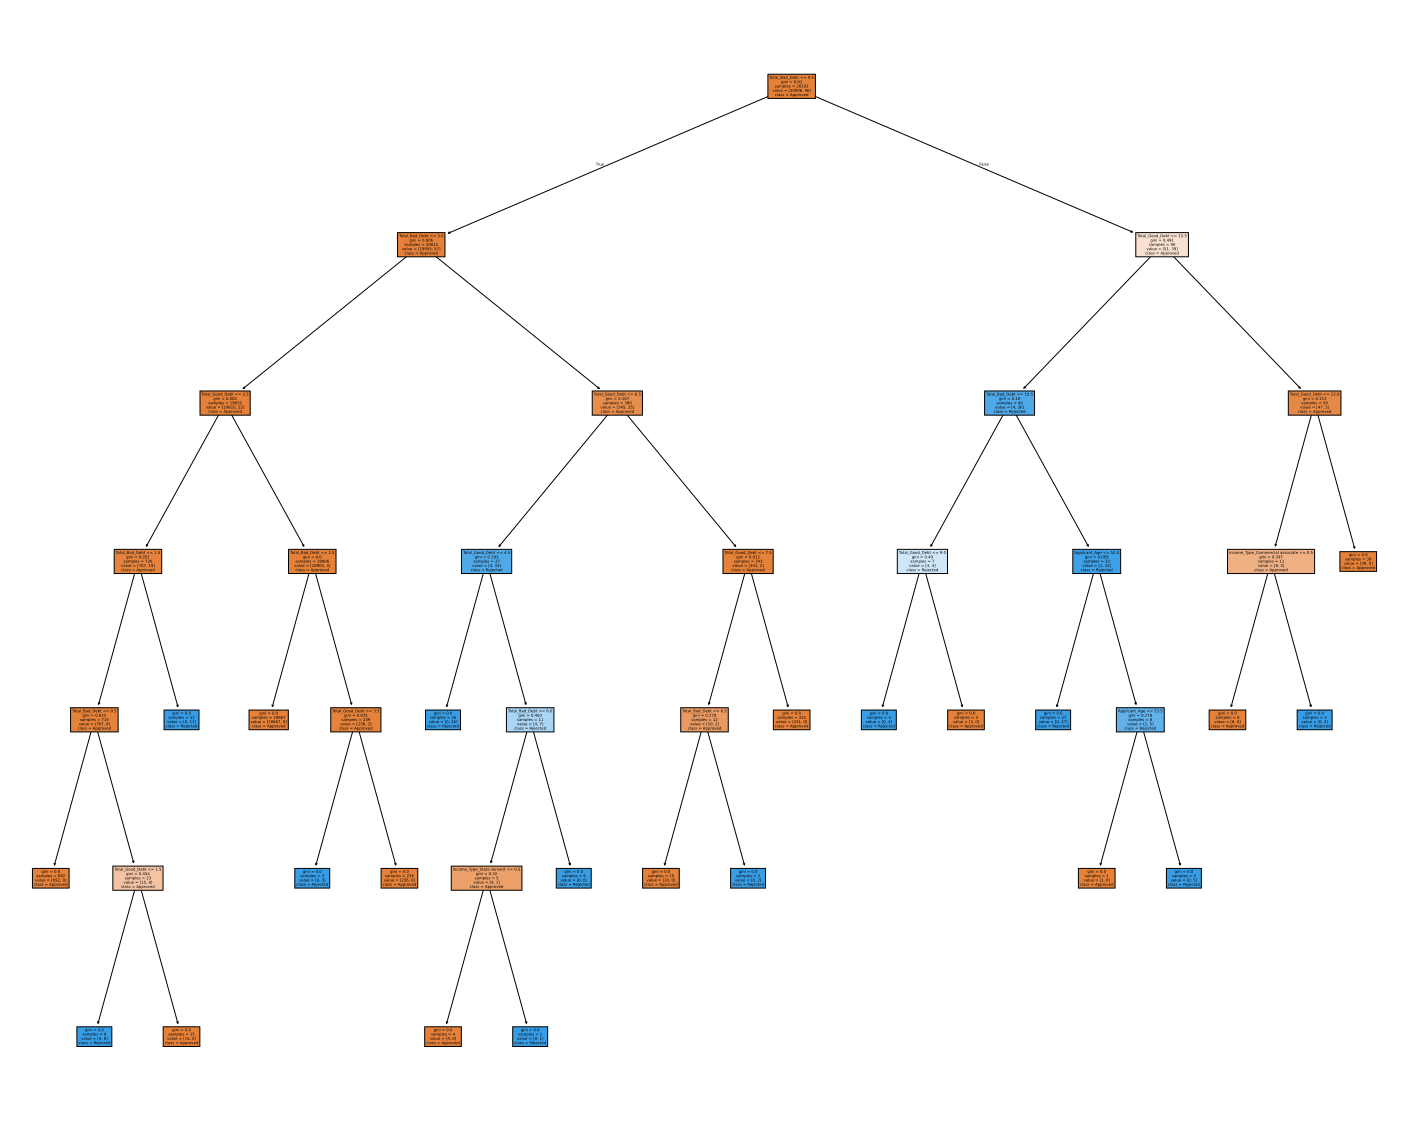

In [10]:
fig = plt.figure(figsize = (25,20))
a = tree.plot_tree(decision_tree = clf_dt,
                   max_depth = None,
                   feature_names = train_X.columns,
                   class_names = clf_dt.classes_,
                   filled = True)

# Saving Decision Tree (.svg is vector-based image format, better quality)
fig.savefig("dt_visual.svg", bbox_inches = 'tight')

plt.show()

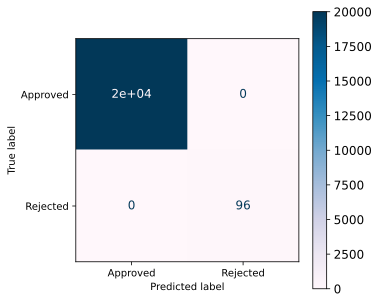

In [11]:
# Predictions on training set
y_pred_train = clf_dt.predict(train_X)

# Now generate confusion matrix
cm = confusion_matrix(train_y, y_pred_train, labels = clf_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf_dt.classes_)

# Specify figure size
fig, ax = plt.subplots(figsize = (5, 5))
plt.rcParams.update({'font.size': 12})

# Display Confusion Matrix
disp.plot(cmap = 'PuBu', ax = ax);

plt.show()

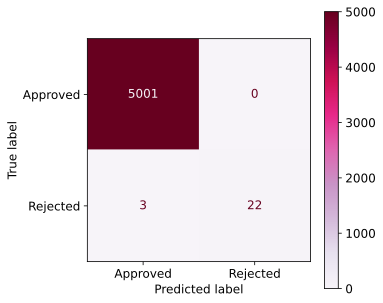

In [12]:
# Predictions on test set
y_pred = clf_dt.predict(test_X)

# Now generate confusion matrix
cm = confusion_matrix(test_y, y_pred, labels = clf_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf_dt.classes_)

# Specify figure size
fig, ax = plt.subplots(figsize = (5, 5))
plt.rcParams.update({'font.size': 12})

# Display Confusion Matrix
disp.plot(cmap = 'PuRd', ax = ax)

# Save as SVG
plt.savefig("dt_confusion_mat.svg", bbox_inches = 'tight');

plt.show()

In [13]:
report = classification_report(test_y, y_pred, output_dict = True)
report_df = pd.DataFrame(report)
display(report_df)

# Save the report as a CSV File
report_df.style.background_gradient(cmap='Purples')
report_df.to_csv('dt_class_report.csv') 

,Approved,Rejected,accuracy,macro avg,weighted avg
precision,0.9994,1.00000,0.999403,0.999700,0.999403
recall,1.0000,0.88000,0.999403,0.940000,0.999403
f1-score,0.9997,0.93617,0.999403,0.967935,0.999384
support,5001.0000,25.00000,0.999403,5026.000000,5026.000000


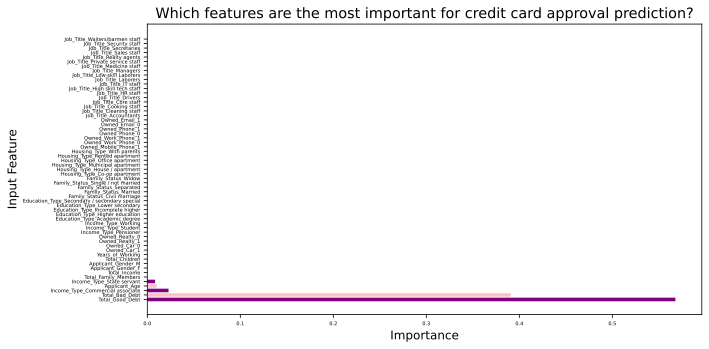

In [14]:
# Storing importance values from the trained model
importance = clf_dt.feature_importances_

# Storing feature importance as a dataframe
feature_imp = pd.DataFrame(list(zip(train_X.columns, importance)),
               columns = ['Feature', 'Importance'])

feature_imp = feature_imp.sort_values('Importance', ascending = False).reset_index(drop = True)

# Bar plot
plt.figure(figsize = (10, 5))
plt.barh(feature_imp['Feature'], feature_imp['Importance'], color = ['purple', 'pink'])

plt.xticks(fontsize=5)                      # x-axis tick labels
plt.yticks(fontsize=5) 
plt.xlabel("Importance")
plt.ylabel("Input Feature")
plt.title('Which features are the most important for credit card approval prediction?') 
plt.tight_layout()
plt.savefig("dt_feature_imp.svg");

plt.show()

### **Saving Pickle**

In [15]:
# Pickle file: saving the trained DT model
# Creating the file where we want to write the model (wb = write binary)
dt_pickle = open('decision_tree.pickle', 'wb') 

# Write DT model to the file
pickle.dump(clf_dt, dt_pickle) 

# Close the file
dt_pickle.close() 